In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn import metrics

plt.style.use('ggplot')

colors = plt.cm.tab10.colors  # or use 'Set3', 'Accent', etc., for more variety
# If there are more than 10 bars, repeat colors or use a larger colormap
colors = list(colors) * (10 // len(colors) + 1)


In [3]:
def interpolate(p1_fpr, p1_tpr, p2_fpr, p2_tpr, x):
    """
    Linear interpolation of TPR at FPR = x between points (p1_fpr, p1_tpr) and (p2_fpr, p2_tpr).
    """
    slope = (p2_tpr - p1_tpr) / (p2_fpr - p1_fpr)
    return p1_tpr + slope * (x - p1_fpr)


def tpr_for_fpr(fprsample, fpr_arr, tpr_arr):
    """
    Implements Algorithm 3's helper that finds / interpolates TPR at a specific FPR.
    Assumes fpr_arr is sorted ascending and has the same length as tpr_arr.
    """
    # Locate the rightmost point whose FPR ≤ fprsample
    i = np.searchsorted(fpr_arr, fprsample, side="right") - 1
    # Edge cases: before first point or exactly at end
    if i < 0:                     # fprsample < smallest FPR in curve
        return tpr_arr[0]
    if fpr_arr[i] == fprsample or i == len(fpr_arr) - 1:
        return tpr_arr[i]
    # Otherwise interpolate between point i and i+1
    return interpolate(fpr_arr[i], tpr_arr[i],
                       fpr_arr[i + 1], tpr_arr[i + 1],
                       fprsample)

def vertical_avg_roc(roc_data):
    '''
    ROC curve averaging function.
    Takes a list of ROC data (each element is a tuple of fpr, tpr, thresholds)
    all the fpr values are concatenated and sorted, then the fpr of each curve is sampled
    at these points, and then averaged
    :param roc_data: list of tuples (fpr, tpr, thresholds)
    :return: tuple (fpr, tpr) of the averaged ROC curve 
    '''
    fprs = []
    tprs = []
    for fpr, tpr, _ in roc_data:
        fprs.append(fpr)
        tprs.append(tpr)
    fprs = np.concatenate(fprs)

    # make sure fprs ends with 1 and starts with 0
    if fprs[0] != 0:
        fprs = np.insert(fprs, 0, 0)
    if fprs[-1] != 1:
        fprs = np.append(fprs, 1)
    
    fprs = np.sort(np.unique(fprs))
    tprs=np.zeros(shape=(len(roc_data),len(fprs)))

    for i, fpr in enumerate(fprs):
        for curve_idx,(fpr_arr, tpr_arr, _) in enumerate(roc_data):
            tprs[curve_idx, i] = tpr_for_fpr(fpr, fpr_arr, tpr_arr)
    tpr = np.mean(tprs, axis=0)
    return fprs, tpr




In [4]:
DATADIR = '/space/gzanardini/emc/emc_singleset_final/'

feat_types=['spectral','cwt','dwt','mst','sst','cc','plv','gcc','gplv','utm']
featnames={'spectral':'S',
           'cwt':'CWT',
           'dwt':'DWT',
           'mst':'mST',
              'sst':'sST',
              'cc':'CC',
                'plv':'PLV',
                'gcc':'GCC',
                'gplv':'GPLV',
                'utm':'UTM'}

def get_predictions_files(datadir, montage, featuretype, length, combiner, seeds, epochs=False):


    if not epochs:
        files = [file for file in os.listdir(datadir) if file.startswith(f'predictions_{montage}_{featuretype}_{length}s_{combiner}_run_') and file.endswith('.csv')]
        files = [file for file in files if any(f'_seed_{seed}' in file for seed in seeds)]

    else:
        files = [file for file in os.listdir(datadir) if file.startswith(f'{featuretype}_{montage}_{length}s_{combiner}_run_') and file.endswith('.csv')] 
       #match the seeds in the file names 
        files = [file for file in files if any( file.split('_')[-1][:-4] == str(seed) for seed in seeds)]

    return files

In [5]:
def compute_threshold_slope(n_epileptic, n_healthy, posterior_threshold=0.6):
    """
    Compute the slope of the ROC threshold line for a given posterior probability.

    Parameters:
    - n_epileptic: int, number of epileptic cases in dataset
    - n_healthy: int, number of healthy subjects in dataset
    - posterior_threshold: float, required posterior probability after positive test (default=0.6)

    Returns:
    - slope: float, multiplier for FPR to get required sensitivity (ROC space)
    """
    # Prior probabilities from data
    p_epileptic = n_epileptic / (n_epileptic + n_healthy)
    p_healthy = 1 - p_epileptic

    # Calculate slope in ROC space
    slope = (posterior_threshold * p_healthy) / (p_epileptic * (1 - posterior_threshold))

    return slope

In [6]:
'''SPECTRAL	Cz	10	std	(3475,4132,3731,4531,3577)
UTM	Bipolar	20	std	(3396,1605,3926,2890,622)
CC	Car	1	std	(4374,2216,4506,1672,3092)
GCC	Car	60	median	(189,3838,902,1822,1600)
PLV	Laplacian	60	kurt	(2483,129,2841,3314,4579)
GPLV	Laplacian	2	std	(602,3569,1889,858,778)
CWT	Bipolar	2	median	(226,3382,1694,446,293)
DWT	Laplacian	10	median	(1571,2618,1098,2591,3115)
SST	Car	10	median	(2126,146,3804,1702,4429)
MST	bipolar 	60	median	(4579,869,754,2291,328)'''


best_runs_whole={
    'spectral' : ('Cz', 10, 'std', (3475, 4132, 3731, 4531, 3577)),
    'utm' : ('BipolarDB', 20, 'std', (3396, 1605, 3926, 2890, 622)),
    'cc' : ('CAR', 1, 'std', (4374, 2216, 4506, 1672, 3092)),
    'gcc' : ('CAR', 60, 'median', (189, 3838, 902, 1822, 1600)),
    'plv' : ('Laplacian', 60, 'kurt', (2483, 129, 2841, 3314, 4579)),
    'gplv' : ('Laplacian', 2, 'std', (602, 3569, 1889, 858, 778)),
    'cwt' : ('BipolarDB', 2, 'median', (226, 3382, 1694, 446, 293)),
    'dwt' : ('Laplacian', 10, 'median', (1571, 2618, 1098, 2591, 3115)),
    'sst' : ('CAR', 10, 'median', (2126, 146, 3804, 1702, 4429)),
    'mst' : ('BipolarDB', 60, 'median', (4579, 869, 754, 2291, 328))
}

<>:40: SyntaxWarning: invalid escape sequence '\g'
<>:40: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_3105874/3099548413.py:40: SyntaxWarning: invalid escape sequence '\g'
  plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$ \geq $ 0.6')


spectral Pooled AUC: 0.67
cwt Pooled AUC: 0.67
dwt Pooled AUC: 0.70
mst Pooled AUC: 0.63
sst Pooled AUC: 0.71
cc Pooled AUC: 0.72
plv Pooled AUC: 0.75
gcc Pooled AUC: 0.67
gplv Pooled AUC: 0.70
utm Pooled AUC: 0.68
Slope for threshold 0.6: 3.79


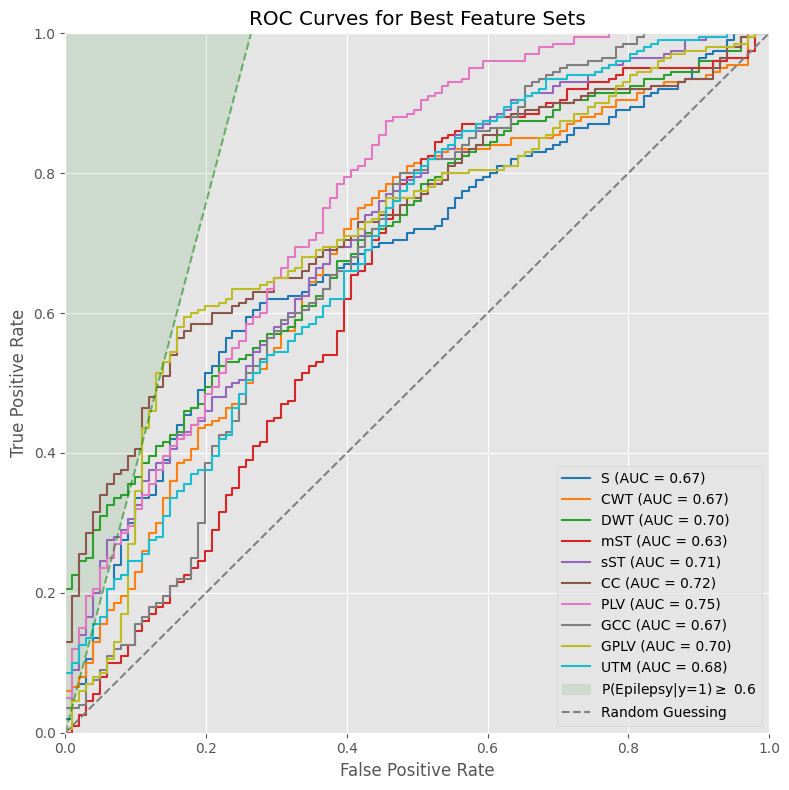

In [7]:
plt.figure(figsize=(8,8))

for feature_type in feat_types:
    montage, length, combiner, seeds = best_runs_whole[feature_type]

    predictions_files = get_predictions_files(DATADIR, montage, feature_type, length, combiner, seeds, epochs=False)

    flag = False
    roc_data = []
    preds=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR, file))
        y_true = df['y_tests'].values
        y_pred = df['y_scores'].values

        if flag == False:# count healthy and epleptic in y true
            n_epileptic = np.sum(y_true)
            n_healthy = len(y_true) - n_epileptic
            flag = True
        # Compute ROC curve
        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_tests', 'y_scores']]],axis=0, ignore_index=True)
    fpr, tpr = vertical_avg_roc(roc_data)
    # pooled ROC curve
    y_true = np.array(preds['y_tests'].values).astype(np.float64)
    y_pred = np.array(preds['y_scores'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)
    plt.step(fpr, tpr, label=f'{featnames[feature_type]} (AUC = {auc_pooled:.2f})', color=colors[feat_types.index(feature_type)], linestyle='solid')
    print(f'{feature_type} Pooled AUC: {auc_pooled:.2f}')


slope = compute_threshold_slope(n_epileptic, n_healthy, posterior_threshold=0.6)

print(f'Slope for threshold 0.6: {slope:.2f}')
# plot a line with this slope, limit the y axis to [0, 1]
plt.plot([0, 1], [0, slope], '--', color='green', alpha=0.5)
#fill above the line
plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$ \geq $ 0.6')
plt.title('ROC Curves for Best Feature Sets')

plt.plot([0, 1], [0, 1], '--', label='Random Guessing', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('emc_ss_whole_roc.pdf', bbox_inches='tight')
plt.show()

<>:65: SyntaxWarning: invalid escape sequence '\g'
<>:65: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_3105874/2521422295.py:65: SyntaxWarning: invalid escape sequence '\g'
  plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$ \geq $ 0.6')


spectral Pooled AUC: 0.65, Average AUC: 0.66
cwt Pooled AUC: 0.52, Average AUC: 0.55
dwt Pooled AUC: 0.63, Average AUC: 0.63
mst Pooled AUC: 0.52, Average AUC: 0.52
sst Pooled AUC: 0.52, Average AUC: 0.55
cc Pooled AUC: 0.68, Average AUC: 0.69
plv Pooled AUC: 0.61, Average AUC: 0.62
gcc Pooled AUC: 0.55, Average AUC: 0.56
gplv Pooled AUC: 0.68, Average AUC: 0.68
utm Pooled AUC: 0.68, Average AUC: 0.68


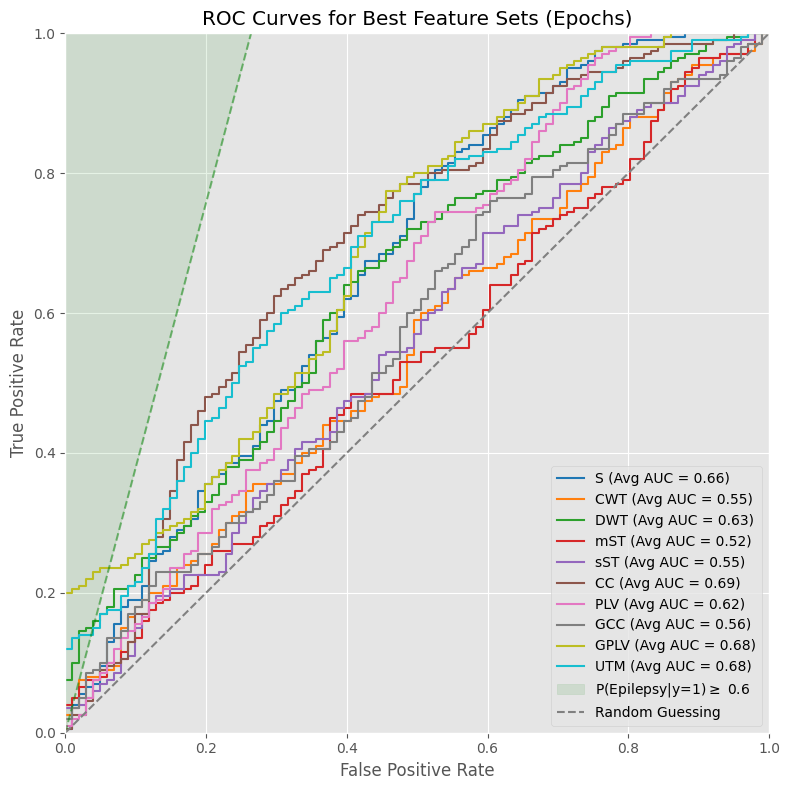

In [10]:
'''SPECTRAL	bipolar	1	kurt	(1166,2186,503,286,3447)
UTM	laplacian	2	kurt	(1866,1219,4289,4140,4881)
CC	car	5	mean	(723,181,2038,3,323)
GCC	laplacian	10	std	(1582,4579,310,784,2179)
PLV	car 	5	std	(963,4509,2624,3468,3584)
GPLV	laplacian	2	median	(2377,1830,3856,2221,3553)
CWT	laplacian	10	std	(3527,1823,1087,2833,3742)
DWT	bipolar	2	kurt	(2722,2632,1460,2850,2154)
SST	car	5	kurt	(2553,121,3846,3812,4199)
MST	laplacian	5	kurt	(485,3452,2442,2954,1627)'''

best_runs_epochs={
    'spectral' : ('BipolarDB', 1, 'kurt', (1166, 2186, 503, 286, 3447)),
    'utm' : ('Laplacian', 2, 'kurt', (1866, 1219, 4289, 4140, 4881)),
    'cc' : ('CAR', 5, 'mean', (723, 181, 2038, 3, 323)),
    'gcc' : ('Laplacian', 10, 'std', (1582, 4579, 310, 784, 2179)),
    'plv' : ('CAR', 5, 'std', (963, 4509, 2624, 3468, 3584)),
    'gplv' : ('Laplacian', 2, 'median', (2377, 1830, 3856, 2221, 3553)),
    'cwt' : ('Laplacian', 10, 'std', (3527, 1823, 1087, 2833, 3742)),
    'dwt' : ('BipolarDB', 2, 'kurt', (2722, 2632, 1460, 2850, 2154)),
    'sst' : ('CAR', 5, 'kurt', (2553, 121, 3846, 3812, 4199)),
    'mst' : ('Laplacian', 5, 'kurt', (485, 3452, 2442, 2954, 1627))
}

plt.figure(figsize=(8,8))
for feature_type in feat_types:
    montage, length, combiner, seeds = best_runs_epochs[feature_type]

    predictions_files = get_predictions_files(DATADIR, montage, feature_type, length, combiner, seeds, epochs=True)
    roc_data = []
    preds=pd.DataFrame(columns=['y_true','y_prob'])

    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR, file))
    
        y_true = df['y_true'].values
        y_pred = df['y_prob'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_true', 'y_prob']]],axis=0, ignore_index=True)

    fpr, tpr = vertical_avg_roc(roc_data)

    # pooled ROC curve
    y_true = np.array(preds['y_true'].values).astype(np.float64)
    y_pred = np.array(preds['y_prob'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)

    auc_avg= metrics.auc(fpr, tpr)
    print(f'{feature_type} Pooled AUC: {auc_pooled:.2f}, Average AUC: {auc_avg:.2f}')

    plot_avg=True

    if plot_avg:
        plt.step(fpr, tpr, label=f'{featnames[feature_type]} (Avg AUC = {auc_avg:.2f})', color=colors[feat_types.index(feature_type)], linestyle='solid')
    else:
        plt.step(fpr_pooled, tpr_pooled, label=f'{featnames[feature_type]} (AUC = {auc_pooled:.2f})', color=colors[feat_types.index(feature_type)], linestyle='solid')

slope = compute_threshold_slope(n_epileptic, n_healthy, posterior_threshold=0.6)
# plot a line with this slope, limit the y axis to [0, 1]
plt.plot([0, 1], [0, slope], '--', color='green', alpha=0.5)
#fill above the line
plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$ \geq $ 0.6')


plt.title('ROC Curves for Best Feature Sets (Epochs)')
plt.plot([0, 1], [0, 1], '--', label='Random Guessing', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


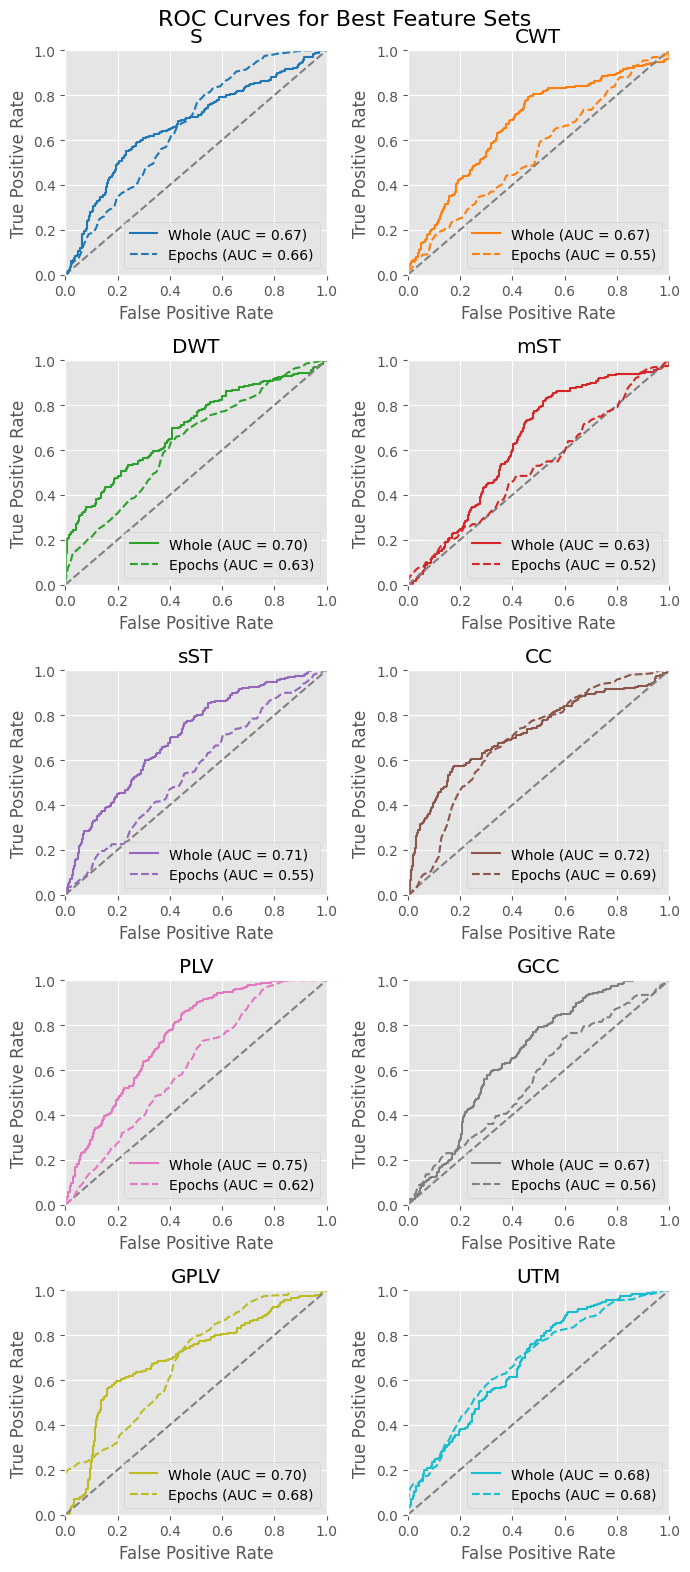

In [9]:
# 5x2 subplots with the ROC curves for each feature type comparing the epochs data with and without IEDs
fig, axs = plt.subplots(5, 2, figsize=(7, 16))
axs = axs.flatten()
for i, feature_type in enumerate(feat_types):
    montage, length, combiner, seeds = best_runs_whole[feature_type]

    predictions_files = get_predictions_files(DATADIR, montage, feature_type, length, combiner, seeds, epochs=False)
    roc_data = []
    preds=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR, file))
        y_true = df['y_tests'].values
        y_pred = df['y_scores'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_tests', 'y_scores']]],axis=0, ignore_index=True)
    fpr, tpr = vertical_avg_roc(roc_data)

    # pooled ROC curve
    y_true = np.array(preds['y_tests'].values).astype(np.float64)
    y_pred = np.array(preds['y_scores'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)

    axs[i].plot(fpr_pooled, tpr_pooled, label=f'Whole (AUC = {auc_pooled:.2f})', color=colors[i], linestyle='solid')
    axs[i].set_title(f'{featnames[feature_type]}')
    axs[i].plot([0, 1], [0, 1], '--', label='', color='gray')
    axs[i].set_xlabel('False Positive Rate')
    axs[i].set_ylabel('True Positive Rate')
    axs[i].set_xlim([0, 1])
    axs[i].set_ylim([0, 1])
    axs[i].legend(loc='lower right')
    axs[i].grid(True)
# Now for the epochs data
for i, feature_type in enumerate(feat_types):
    montage, length, combiner, seeds = best_runs_epochs[feature_type]

    predictions_files = get_predictions_files(DATADIR, montage, feature_type, length, combiner, seeds, epochs=True)
    roc_data = []
    preds=pd.DataFrame(columns=['y_true','y_prob'])

    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR, file))
    
        y_true = df['y_true'].values
        y_pred = df['y_prob'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_true', 'y_prob']]],axis=0, ignore_index=True)

    fpr, tpr = vertical_avg_roc(roc_data)

    # pooled ROC curve
    y_true = np.array(preds['y_true'].values).astype(np.float64)
    y_pred = np.array(preds['y_prob'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)

    auc_avg= metrics.auc(fpr, tpr)
    axs[i].plot(fpr, tpr, label=f'Epochs (AUC = {auc_avg:.2f})', color=colors[i], linestyle='dashed')
    axs[i].legend(loc='lower right')

plt.suptitle('ROC Curves for Best Feature Sets', fontsize=16)
plt.tight_layout()
plt.show()